In [11]:
#hide
options(jupyter.plot_scale=3)
options(repr.plot.width=6,repr.plot.height=6,repr.plot.res=300)
options(jupyter.rich_display=FALSE)
options(max.print=1000)

# (시험) R 입문 중간고사 draft
- toc:true
- branch: master
- badges: true
- comments: true
- author: 최규빈
- hide: true
- categories: [R]

### 100라커 

복도에 100개의 라커가 있다. 복도를 어떤 남자가 100개의 라커 문을 전부 연다. 그리고 나서 짝수 번호의 라커를 전부 닫는다. 그 다음에는 번호가 3의 배수인 라커를 순서대로 찾아다니며 열려 있으면 닫고, 닫혀 있으면 연다. 그 다음에는 번호가 4의 배수인 라커를 순서대로 찾아다니며 열려있으면 닫고, 닫혀있으면 연다. 이후에 5의 배수, 6의 배수 .. 인 라커를 순서대로 찾아다니며 행동을 반복한다. 이런식으로 복도를 100번 지나가면 열린 라커의 문은 몇개가 되겠는가? 

In [12]:
library(tidyverse)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.5     ✔ purrr   0.3.4
✔ tibble  3.1.3     ✔ dplyr   1.0.7
✔ tidyr   1.1.3     ✔ stringr 1.4.0
✔ readr   1.4.0     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()



In [13]:
x=rep(FALSE,100)

In [14]:
x

  [1] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [13] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [25] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [37] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [49] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [61] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [73] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [85] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [97] FALSE FALSE FALSE FALSE

In [15]:
f<-function(x) !x

In [16]:
x %>% f

  [1] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [16] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [31] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [46] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [61] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [76] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [91] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE

In [17]:
g<-function(x,a){
    x[(1:100) %% a == 0]=f(x[(1:100) %% a == 0])
    x
}                                   

In [18]:
x %>% f %>% g(2)

  [1]  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE
 [13]  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE
 [25]  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE
 [37]  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE
 [49]  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE
 [61]  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE
 [73]  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE
 [85]  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE
 [97]  TRUE FALSE  TRUE FALSE

In [19]:
x # 
x=f(x) # 1회 복도를 지나감
for(i in 2:100){
    x= g(x,i) 
}

  [1] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [13] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [25] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [37] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [49] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [61] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [73] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [85] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [97] FALSE FALSE FALSE FALSE

In [20]:
sum(x)

[1] 10

### 무궁화 꽃이 피었습니다. 

> youtube: https://www.youtube.com/watch?v=jypCdAI-Y7I

총 456명의 참가자가 '무궁화 꽃이 피었습니다' 게임에 참가한다. 기본적인 게임의 규칙은 아래와 같다. 

- 술래는 총 10회간 벽을 보고 '무궁화 꽃이 피었습니다' 를 외친다. 

- 참가자는 술래가 있는 곳 까지 이동해야 살 수 있다. 

- 술래는 벽을 보고 '무궁화 꽃이 피었습니다'를 외치다가 구호가 끝남과 동시에 뒤를 돌아본다. 이때 움직이는 사람은 **죽는다**

따라서 참가자는 술래가 벽을 보고 '무궁화 꽃이 피었습니다'를 외치는 동안만 이동할 수 있다. 욕심을 부려 더 이동하고자 하면 죽을 수 있다. 반대로 죽는 것을 지나치게 두려워한 나머지 매턴마다 조금씩만 이동한다면 10회의 제한횟수 내에 술래에게 도달하지 못하여 죽는다. 

게임환경과 관련된 세부적인 설정은 아래와 같다. 

- 술래와 참가자의 거리는 35이다. 

- 술래는 처음 벽을 보고 $x$초간 무궁화 꽃이 피었습니다를 외친다. 

- 모든 참가자는 1초에 거리1이상 움직일 수 없다고 가정한다. (예를들어 2.4초 동안은 최대 2.4의 거리를 이동할 수 있다. 반면 이동을 원치않으면 0의 거리만큼 움직이므로 0~2.4사이의 거리를 움직일 수 있다) 

술래와 참가자에 대한 설정값은 아래와 같다. 

***술래에 대한 설정값***

- 처음에는 술래가 10초간 무궁화 꽃이 피었습니다를 외친다. 

- 그 다음에는 술래가 9.5초간 무궁화 꽃이 피었습니다를 외친다. 

- 그 다음에도 0.5초씩 구호를 외치는 시간을 줄인다. 이것을 10회 반복한다. 

***참가자에 대한 설정값*** 

- 처음에는 참가자가 "본인의번호/100"을 계산하여 나온 숫자만큼 움직인다. 즉 10번 참가자는 0.1의 거리를 움직이고 456번 참가자는 4.56의 거리를 움직인다. 

- 그 다음은 처음에 본인이 이동했던 거리에 1씩 더하여 움직인다. 즉 10번 참가자는 1.1의 거리를 움직이고 456번 참가자는 5.56의 거리를 움직인다. 


`-` 예시2

300번 참가자의 경우 아래와 같이 이동하므로 

| |1회 |2회 |3회 | 4회 | 5회 | 6회 |
|:-:|:-:|:-:|:-:| :-:|:-:|:-:|
술래의 외침시간  | 10  | 9.5 | 9.0 | 8.5 | 8.0 | 7.5 |
참가자의 이동폭  | 3 | 4 | 5 | 6 | 7 | 7.5 |
참가자의 이동거리 | 3 | 7 | 12 | 18 | 25 | 32.5 (32.5까지 이동후 사망) |

생존할 수 없다. 

`-` 예시2

350번 참가자의 경우 아래와 같이 이동하므로 

| |1회 |2회 |3회 | 4회 | 5회 | 6회 |
|:-:|:-:|:-:|:-:| :-:|:-:|:-:|
술래의 외침시간  | 10  | 9.5 | 9.0 | 8.5 | 8.0 | 7.5 |
참가자의 이동폭  | 3.5 | 4.5 | 5.5 | 6.5 | 7.5 | 8.5 |
참가자의 이동거리 | 3.5 | 8 | 13.5 | 20 | 27.5 | 35 (정확하게 7.5초간 이동하고 살아남는다) |

생존 할 수 있다. 

`-` 예시3

400번 참가자의 경우 아래와 같이 이동하므로 

| |1회 |2회 |3회 | 4회 | 5회 | 6회 |
|:-:|:-:|:-:|:-:| :-:|:-:|:-:|
술래의 외침시간  | 10  | 9.5 | 9.0 | 8.5 | 8.0 | 7.5 |
참가자의 이동폭  | 4 | 5 | 6 | 7 | 8 | 5 |
참가자의 이동거리 | 4 | 9 | 15 | 22 | 30 | 35 (5초간만 이동하면 35만큼 이동하므로 살아남는다)|

생존 할 수 있다. 

#### (a) 1번, 67번, 218번, 456번 참가자의 생존여부를 확인하는 함수를 작성하라. 

#### (b) 전체 생존자중 몇명이 살아남는지 계산하라. 

In [57]:
surv=function(num,d){
    x=seq(10,5.5,by=-0.5)
    stride = 0:9+num/100 
    live = x>=stride
    live[sum(live)+1] = sum(stride[1:sum(live)])+x[sum(live)+1] >= d
    #print(rbind(x[live],stride[live]))
    #print(cumsum(stride[live]))
    sum(stride[live]) > d
}

In [49]:
say = c(20:11/2) #술래의 외침시간


f <- function(n){ #n = 참가자의 번호
    move = c(n/100)
    for (i in 2:10){
        move[i] = move[i-1] + 1
        if (sum(move) >= 35){
            return("생존")
            break
        }
        if (move[i] > say[i]){
            return("사망")
            
            break
        }
    }
}
    

In [51]:
say

 [1] 10.0  9.5  9.0  8.5  8.0  7.5  7.0  6.5  6.0  5.5

In [56]:
f(400)

[1] "생존"

In [58]:
f(1)
f(67)
f(218)
f(456)

[1] "사망"

[1] "사망"

[1] "생존"

[1] "사망"

In [65]:
f(100)

[1] "생존"

In [67]:
surv(100,35)

[1] FALSE

In [61]:
A=rep(0,456*2) 
dim(A)<-c(456,2) 
for (i in 1:456){
    A[i,]<-c(f(i),surv(i,35))
}

In [64]:
as_tibble(A) %>% write_csv("test.csv")

In [60]:
c(surv(1,35),surv(67,35),surv(218,35),surv(456,35))

[1] FALSE FALSE  TRUE FALSE

In [23]:
sum=0
for (i in 1:456) sum=sum+f(i,35)
sum

[1] 85

### 시각화 

다음은 인터넷에서 어떠한 자료를 다운받아 매트릭스로 저장하는 코드이다. 
```R
df=read.csv("https://raw.githubusercontent.com/miruetoto/yechan/master/_notebooks/round2.csv")
mat=as.matrix(df)
```
매트릭스는 `mat`이라는 변수에 저장되어 있다. 

#### (a) mat의 첫번째 열을 $x$, 두번째열을 $y$로 생각하고 plot함수를 통하여 아래와 같은 산점도를 그려라. 

`-` 힌트: 아래와 같은 그림이 나와야 한다. 

In [24]:
df=read.csv("https://raw.githubusercontent.com/miruetoto/yechan/master/_notebooks/round2.csv")

In [25]:
mat=as.matrix(df)

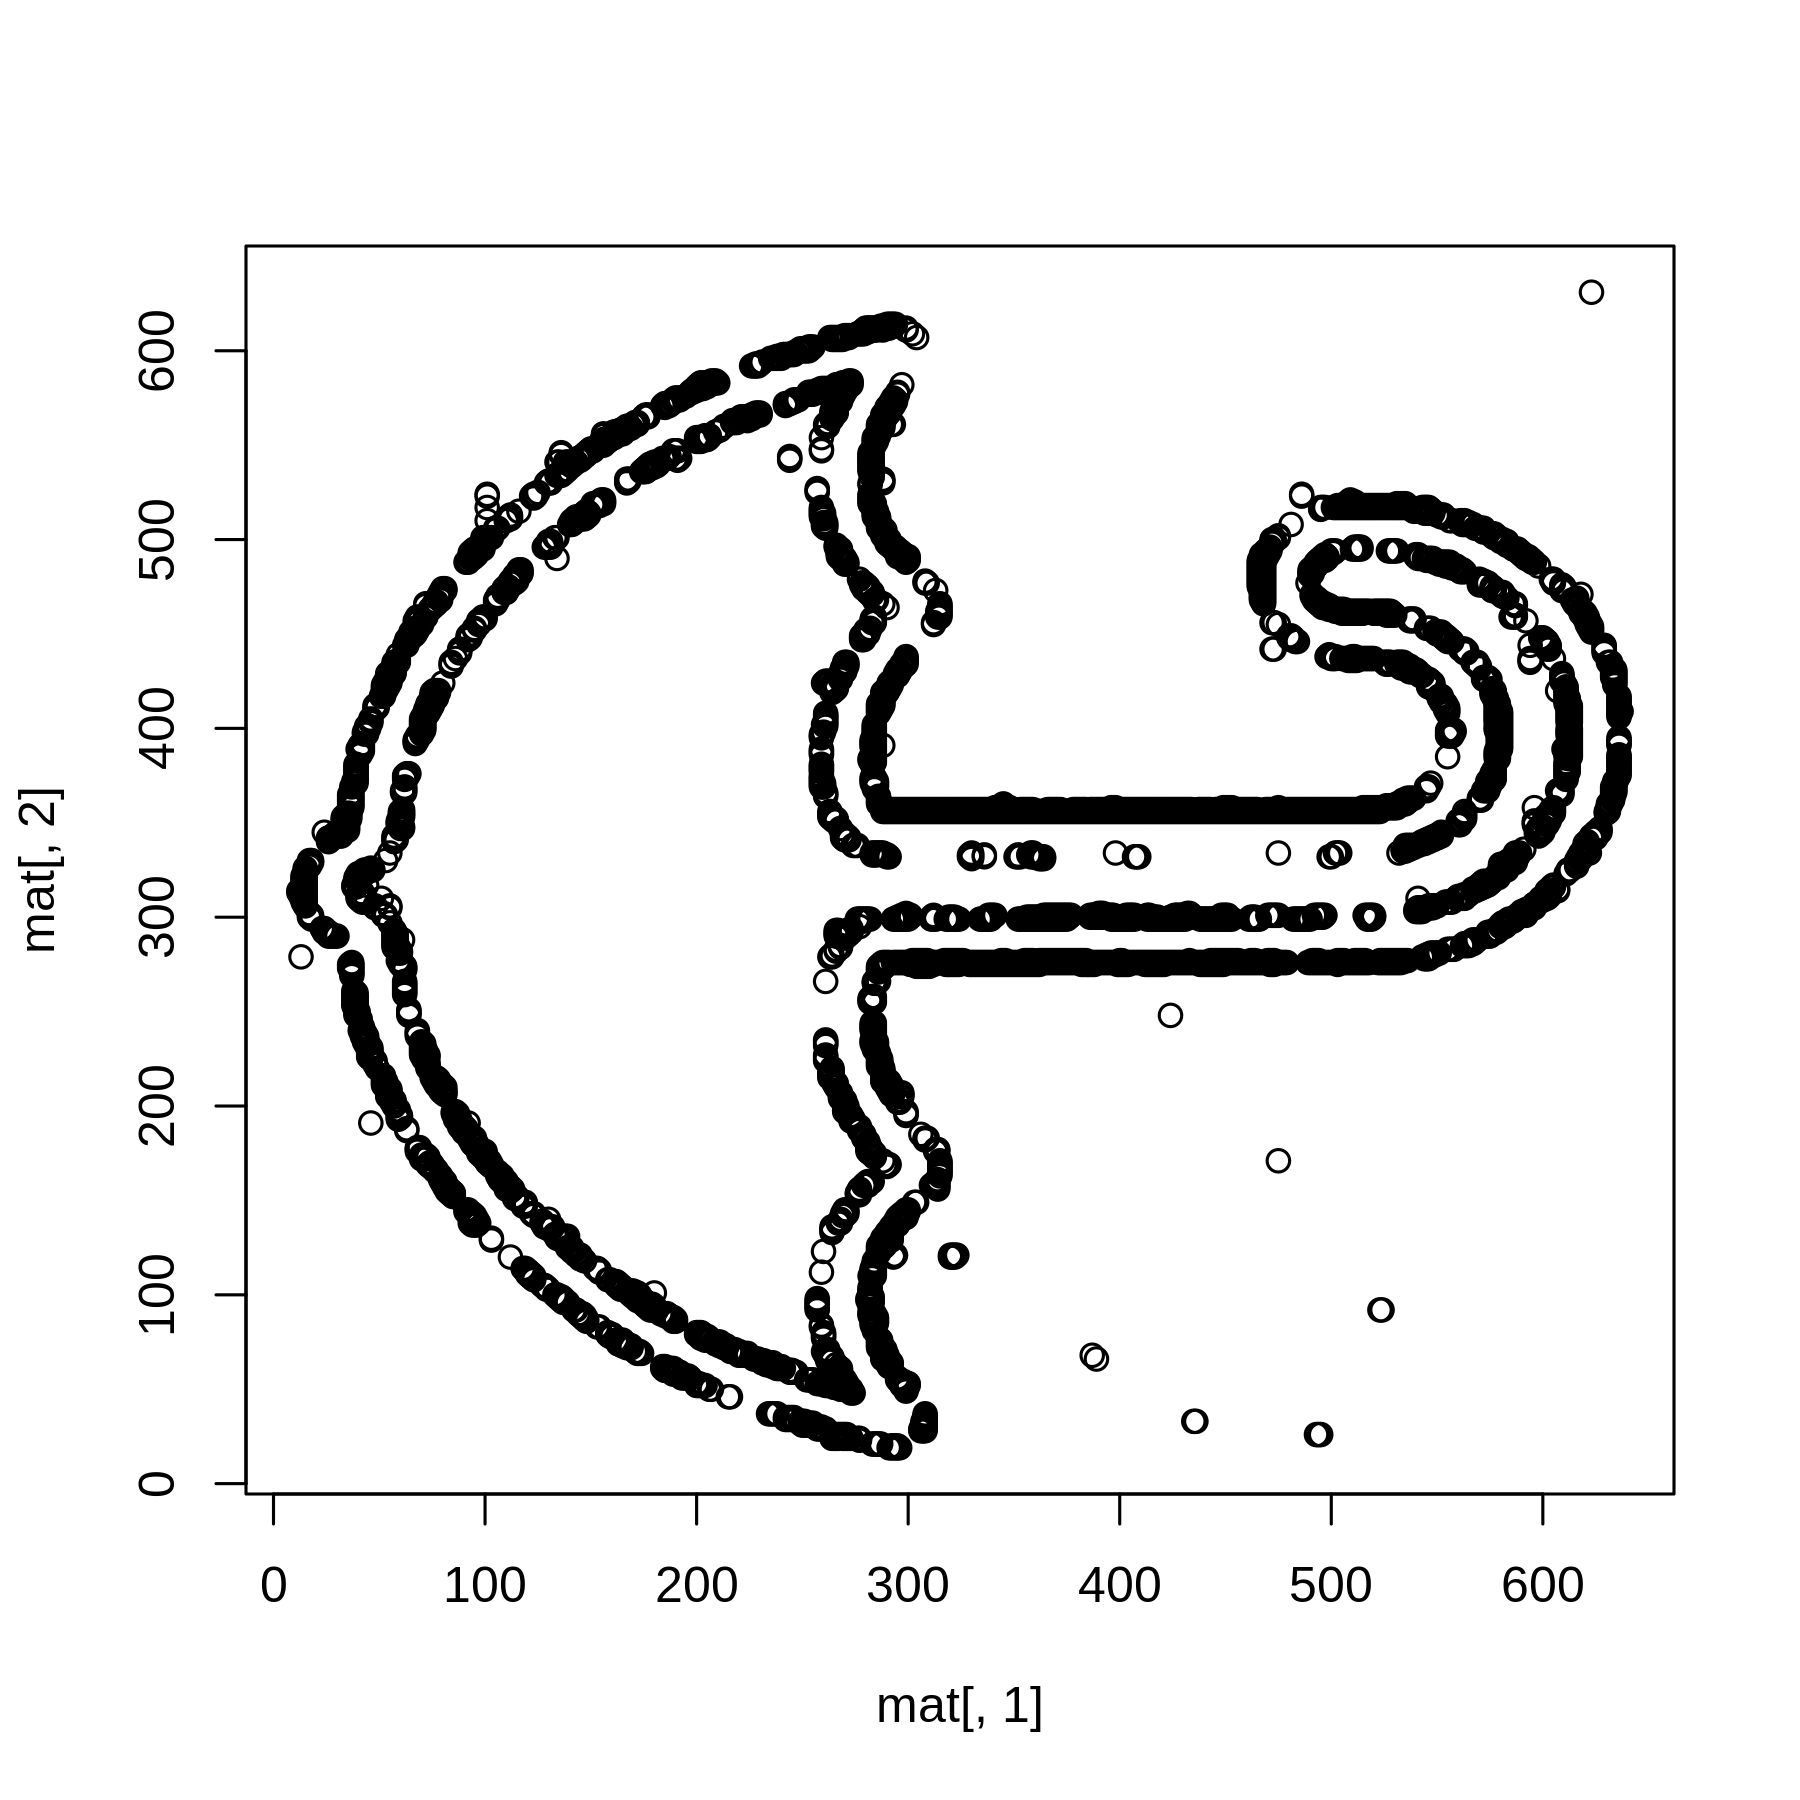

In [26]:
plot(mat[,1],mat[,2])

#### (b) 매트릭스의 첫번째 행(first row)를 출력하는 코드를 작성하라.

`-` 힌트: 출력결과는 (12,313)이 나와야 한다. 

In [45]:
mat[1,]

  x   y 
 12 313 

#### (c) (b)의 결과에 아래의 연산을 수행하는 코드를 작성하라. 

$$
\begin{bmatrix}
0 & -1 \\
-1 & 0 
\end{bmatrix} \begin{bmatrix}
12 \\
313
\end{bmatrix} 
$$

#### (d) (b)-(c) 과정을 mat의 모등행에 반복하여 새로운 매트릭스를 만들어라. 

`-` 힌트: 아래의 과정을 따른다.  
- (i) mat와 동일한 dim을 가진 mat2를 만든다. 
- (ii) mat의 첫번째 행에 (b)-(c)의 과정을 적용하여 길이가 2인 벡터를 얻는다. 
- (iii) (ii)의 과정에서 얻은 벡터를 새로운 매트릭스의 첫번째 행에 넣는다. 
- (iv) mat의 두번째 행에 대하여 (ii)-(iii)의 과정을 반복한다. 이후 세번째, 네번째 행에 대하여 (ii)-(iii)의 과정을 반복한다. 

#### (e) (d)의 결과로 생성되 매트릭스의 첫번째 열을 x, 두번째 열을 y로 하고 산점도를 그려라. 

`-` 아래와 같은 그림이 나와야 한다. 

In [37]:
A=rbind(c(0,-1),c(-1,0))

In [35]:
A%*% mat[1,]

     [,1]
[1,] 313 
[2,] -12 

In [39]:
dim(mat)

[1] 5513    2

In [41]:
mat2=mat*0

In [42]:
for (i in 1:5513) mat2[i,] = mat[i,]%*% A

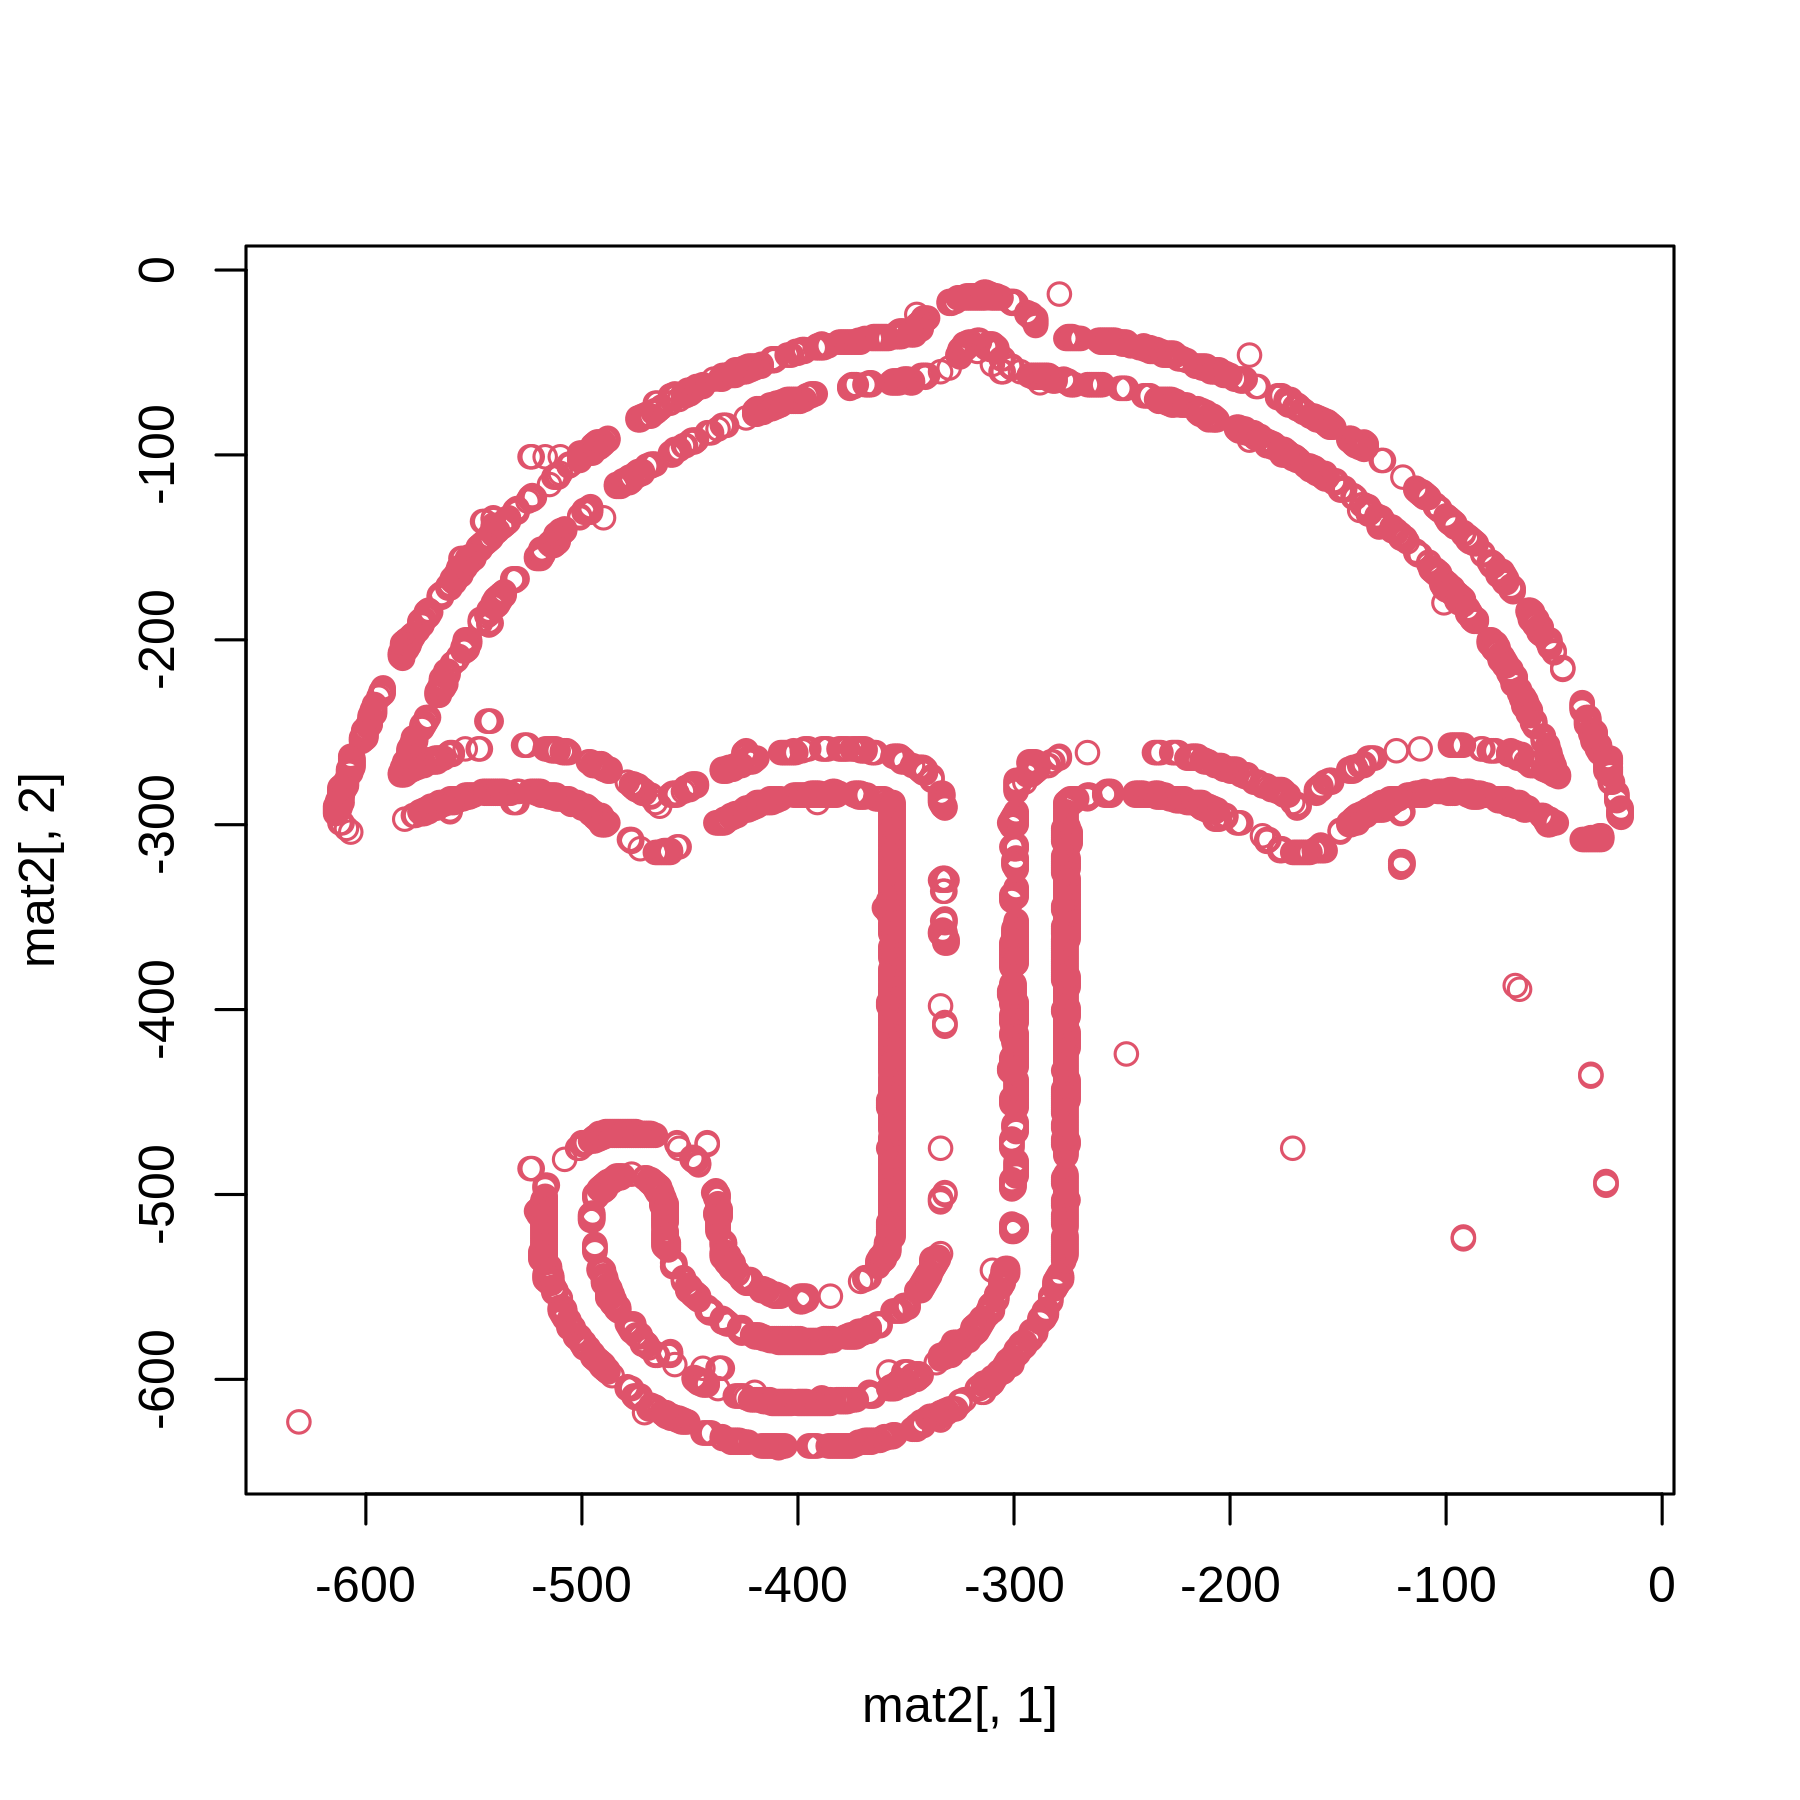

In [44]:
plot(mat2[,1],mat2[,2],col=2)